# Setup

In [16]:
%load_ext autoreload
%autoreload 2

from bids import BIDSLayout
from nilearn.image import mean_img
from nilearn.plotting import plot_anat, plot_img
from matplotlib import pyplot as plt
import nibabel as nib
import cortex
import os
import pandas as pd
import numpy as np
import utils
from transformers import AutoTokenizer, AutoModel

DATA_DIR = './fmri'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load Data

In [2]:
# Here we're using an example BIDS dataset that's bundled with the pybids tests
DATASET = 'ds003696'
data_path = os.path.join(DATA_DIR, DATASET)

# Initialize the layout, set derivatives to true to include pre-processed fmri
# IMPORTANT: If there is an error, just follow the instructions and create a `dataset_description.json` at the root of the `derivatives` folder
layout = BIDSLayout(data_path, derivatives=True)

# Print some basic information about the layout
layout

BIDS Layout: ...rdances FMRI/HW2/fmri/ds003696 | Subjects: 30 | Sessions: 60 | Runs: 240

In [3]:
all_files = layout.get()
print("There are {} files in the layout.".format(len(all_files)))
print("\nThe first 10 files are:")
all_files[:10]

There are 2349 files in the layout.

The first 10 files are:


[<BIDSFile filename='/mnt/d/Affordances FMRI/HW2/fmri/ds003696/CHANGES'>,
 <BIDSJSONFile filename='/mnt/d/Affordances FMRI/HW2/fmri/ds003696/dataset_description.json'>,
 <BIDSJSONFile filename='/mnt/d/Affordances FMRI/HW2/fmri/ds003696/derivatives/dataset_description.json'>,
 <BIDSJSONFile filename='/mnt/d/Affordances FMRI/HW2/fmri/ds003696/derivatives/dataset_description.json'>,
 <BIDSDataFile filename='/mnt/d/Affordances FMRI/HW2/fmri/ds003696/derivatives/preproc-DPABI/sub-101/ses-01/func/sub-101_ses-01_task-affordance_run-1_desc-DPABI_beh.tsv'>,
 <BIDSJSONFile filename='/mnt/d/Affordances FMRI/HW2/fmri/ds003696/derivatives/preproc-DPABI/sub-101/ses-01/func/sub-101_ses-01_task-affordance_run-1_desc-DPABI_bold.json'>,
 <BIDSImageFile filename='/mnt/d/Affordances FMRI/HW2/fmri/ds003696/derivatives/preproc-DPABI/sub-101/ses-01/func/sub-101_ses-01_task-affordance_run-1_desc-DPABI_bold.nii.gz'>,
 <BIDSDataFile filename='/mnt/d/Affordances FMRI/HW2/fmri/ds003696/derivatives/preproc-DPABI/s

In [4]:
layout.to_df()

entity,path,datatype,extension,run,session,subject,suffix,task
0,/mnt/d/Affordances FMRI/HW2/fmri/ds003696/data...,NaN,.json,NaN,NaN,NaN,description,NaN
1,/mnt/d/Affordances FMRI/HW2/fmri/ds003696/deri...,NaN,.json,NaN,NaN,NaN,description,NaN
2,/mnt/d/Affordances FMRI/HW2/fmri/ds003696/part...,NaN,.json,NaN,NaN,NaN,participants,NaN
3,/mnt/d/Affordances FMRI/HW2/fmri/ds003696/part...,NaN,.tsv,NaN,NaN,NaN,participants,NaN
4,/mnt/d/Affordances FMRI/HW2/fmri/ds003696/sub-...,func,.json,1,01,101,bold,affordance
...,...,...,...,...,...,...,...,...
2343,/mnt/d/Affordances FMRI/HW2/fmri/ds003696/deri...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2344,/mnt/d/Affordances FMRI/HW2/fmri/ds003696/deri...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2345,/mnt/d/Affordances FMRI/HW2/fmri/ds003696/deri...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2346,/mnt/d/Affordances FMRI/HW2/fmri/ds003696/deri...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Get preprocessed data
preproc_layout = layout.derivatives['derivatives']
preproc_layout

BIDS Layout: .../HW2/fmri/ds003696/derivatives | Subjects: 30 | Sessions: 60 | Runs: 240

In [7]:
print(preproc_layout.get_subjects())
print(preproc_layout.get_tasks())
print(preproc_layout.get_entities())

['101', '102', '103', '104', '105', '106', '107', '108', '110', '111', '113', '115', '116', '118', '120', '121', '122', '124', '125', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139']
['affordance', 'localizer']
{'subject': <Entity subject (pattern=[/\\]+sub-([a-zA-Z0-9+]+), dtype=<class 'str'>)>, 'session': <Entity session (pattern=[_/\\]+ses-([a-zA-Z0-9+]+), dtype=<class 'str'>)>, 'sample': <Entity sample (pattern=[_/\\]+sample-([a-zA-Z0-9+]+), dtype=<class 'str'>)>, 'task': <Entity task (pattern=[_/\\]+task-([a-zA-Z0-9+]+), dtype=<class 'str'>)>, 'tracksys': <Entity tracksys (pattern=[_/\\]+tracksys-([a-zA-Z0-9+]+), dtype=<class 'str'>)>, 'acquisition': <Entity acquisition (pattern=[_/\\]+acq-([a-zA-Z0-9+]+), dtype=<class 'str'>)>, 'nucleus': <Entity nucleus (pattern=[_/\\]+nuc-([a-zA-Z0-9+]+), dtype=<class 'str'>)>, 'volume': <Entity volume (pattern=[_/\\]+voi-([a-zA-Z0-9+]+), dtype=<class 'str'>)>, 'ceagent': <Entity ceagent (pattern=[_/\\]+ce-([a-zA-Z0-

# Visualize subject
Here we load the fmri and anatomical data for one subject's run and visualize their mean activity over time using `nilearn`.

In [5]:
# Retrieve filenames of all BOLD runs for subject
subject = '102'
fmri_files = preproc_layout.get(subject=subject, extension='nii.gz', datatype='func', return_type='filename', task = 'affordance')
table_files = preproc_layout.get(subject=subject, extension='.tsv', suffix = 'events', return_type='filename', task = 'affordance')
anat_file = preproc_layout.get(subject=subject, extension='nii.gz', datatype='anat', return_type='filename')[0]
print("functional")
print(fmri_files)
print("useful tables")
print(table_files)
print("anatomical")
print(anat_file)

functional
['/mnt/d/Affordances FMRI/HW2/fmri/ds003696/derivatives/preproc-DPABI/sub-102/ses-01/func/sub-102_ses-01_task-affordance_run-1_desc-DPABI_bold.nii.gz', '/mnt/d/Affordances FMRI/HW2/fmri/ds003696/derivatives/preproc-DPABI/sub-102/ses-01/func/sub-102_ses-01_task-affordance_run-2_desc-DPABI_bold.nii.gz', '/mnt/d/Affordances FMRI/HW2/fmri/ds003696/derivatives/preproc-DPABI/sub-102/ses-01/func/sub-102_ses-01_task-affordance_run-3_desc-DPABI_bold.nii.gz', '/mnt/d/Affordances FMRI/HW2/fmri/ds003696/derivatives/preproc-DPABI/sub-102/ses-01/func/sub-102_ses-01_task-affordance_run-4_desc-DPABI_bold.nii.gz', '/mnt/d/Affordances FMRI/HW2/fmri/ds003696/derivatives/preproc-DPABI/sub-102/ses-02/func/sub-102_ses-02_task-affordance_run-5_desc-DPABI_bold.nii.gz', '/mnt/d/Affordances FMRI/HW2/fmri/ds003696/derivatives/preproc-DPABI/sub-102/ses-02/func/sub-102_ses-02_task-affordance_run-6_desc-DPABI_bold.nii.gz', '/mnt/d/Affordances FMRI/HW2/fmri/ds003696/derivatives/preproc-DPABI/sub-102/ses-0

/tmp/ipykernel_1305359/2140612929.py:3: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mean = mean_img(fmri_img)


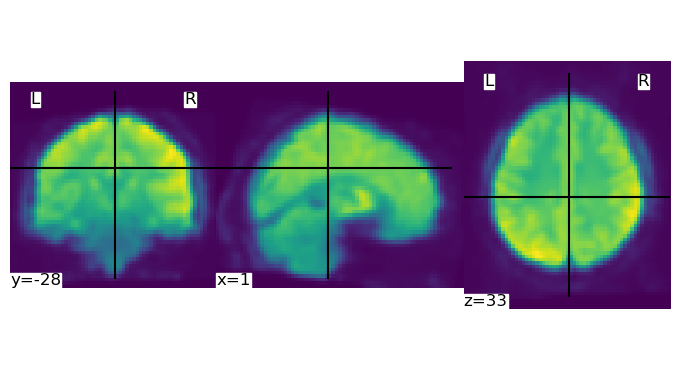

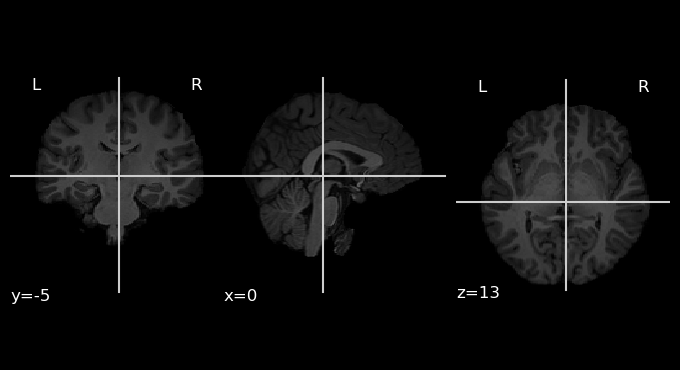

In [24]:
run = 0
fmri_img = fmri_files[run]
mean = mean_img(fmri_img)
plot_img(mean)
plot_anat(anat_file)

# Regression

## Prepare fMRI data

For a subset of subjects, collect their volumetric fMRI data. Since we are ignoring the novel objects for now, we need to filter out these responses.

In [6]:
# Collect all the fmri data for given subjects
fmri_data = utils.get_all_fmri_data(preproc_layout, n_samples=5)
# Get all stimuli as dataframe-- currently function only returns familiar categories
stim_data = utils.get_all_stimuli(data_path)

In [7]:
# For each run, create a mask that is shared across subjects and extract the relevant responses
runs = stim_data['run'].nunique()
all_TRs = 185
TR_idx = []
for run in range(runs):
    onsets = stim_data.loc[stim_data['run'] == run + 1, 'onset'].values
    TR_idx.append(np.arange(all_TRs)[onsets // 2 + 4])

# Filter fmri data
for subject in range(len(fmri_data)):
    for run in range(runs):
        fmri_data[subject][run] = fmri_data[subject][run][TR_idx[run]]

## Prepare regressors

In [8]:
size_embedding = 768
model_name = "bert-base-uncased"  # Change to your desired model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
embedding_layer = model.get_input_embeddings()

template_regressors = np.zeros((len(stim_data), size_embedding * 3))
for row in stim_data.itertuples():
    template_regressors[row.Index, :size_embedding] = utils.get_single_string_embedding(row.object1, tokenizer, embedding_layer)
    template_regressors[row.Index, size_embedding:2*size_embedding] = utils.get_single_string_embedding(row.object2, tokenizer, embedding_layer)
    template_regressors[row.Index, 2*size_embedding:3*size_embedding] = utils.get_multi_string_embedding([row.object1, row.object2], tokenizer, embedding_layer)

## Prepare train and test data

In [9]:
# Load the zscore function
from scipy.stats import zscore

# Using a list insures the order remains the same for the data and the features
training_data = np.vstack(np.vstack(fmri_data[:-1]))
test_data = np.vstack(fmri_data[-1])

n_train_subjs = len(fmri_data) - 1
n_test_subjs = 1
training_word_emb =  np.tile(template_regressors, (n_train_subjs, 1))
test_word_emb = template_regressors

# Downsample voxels
n_voxels = 10000
voxel_dims = np.random.choice(training_data.shape[1], n_voxels, replace = False)
training_data = training_data[:, voxel_dims]
test_data = test_data[:, voxel_dims]

print("training data (num pts, num voxels): ", training_data.shape)
print("test data (num pts, num voxels): ", test_data.shape)
print("training word embeddings (num pts, num voxels): ", training_word_emb.shape)
print("test word embeddings (num pts, num voxels): ", test_word_emb.shape)

training data (num pts, num voxels):  (2560, 10000)
test data (num pts, num voxels):  (640, 10000)
training word embeddings (num pts, num voxels):  (2560, 2304)
test word embeddings (num pts, num voxels):  (640, 2304)


## Fit Ridge Regression

In [11]:
from ridge_tools import cross_val_ridge

# optional to change the function
weights_word, lambda_word = cross_val_ridge(training_word_emb, training_data, n_splits=4,
                                            lambdas=np.array([10**i for i in range(-6, 10)]), method="ridge_sk")

/mnt/d/Affordances FMRI/HW2/ridge_tools.py:20: RuntimeWarning: divide by zero encountered in divide
  return np.nan_to_num(1 - SSres / SStot)
/mnt/d/Affordances FMRI/HW2/ridge_tools.py:20: RuntimeWarning: invalid value encountered in divide
  return np.nan_to_num(1 - SSres / SStot)
/mnt/d/Affordances FMRI/HW2/ridge_tools.py:20: RuntimeWarning: divide by zero encountered in divide
  return np.nan_to_num(1 - SSres / SStot)
/mnt/d/Affordances FMRI/HW2/ridge_tools.py:20: RuntimeWarning: invalid value encountered in divide
  return np.nan_to_num(1 - SSres / SStot)
/mnt/d/Affordances FMRI/HW2/ridge_tools.py:20: RuntimeWarning: divide by zero encountered in divide
  return np.nan_to_num(1 - SSres / SStot)
/mnt/d/Affordances FMRI/HW2/ridge_tools.py:20: RuntimeWarning: invalid value encountered in divide
  return np.nan_to_num(1 - SSres / SStot)
/mnt/d/Affordances FMRI/HW2/ridge_tools.py:20: RuntimeWarning: divide by zero encountered in divide
  return np.nan_to_num(1 - SSres / SStot)
/mnt/d/Af

fold 0 of 4, time taken: 12.666223526000977


/mnt/d/Affordances FMRI/HW2/ridge_tools.py:20: RuntimeWarning: divide by zero encountered in divide
  return np.nan_to_num(1 - SSres / SStot)
/mnt/d/Affordances FMRI/HW2/ridge_tools.py:20: RuntimeWarning: invalid value encountered in divide
  return np.nan_to_num(1 - SSres / SStot)
/mnt/d/Affordances FMRI/HW2/ridge_tools.py:20: RuntimeWarning: divide by zero encountered in divide
  return np.nan_to_num(1 - SSres / SStot)
/mnt/d/Affordances FMRI/HW2/ridge_tools.py:20: RuntimeWarning: invalid value encountered in divide
  return np.nan_to_num(1 - SSres / SStot)
/mnt/d/Affordances FMRI/HW2/ridge_tools.py:20: RuntimeWarning: divide by zero encountered in divide
  return np.nan_to_num(1 - SSres / SStot)
/mnt/d/Affordances FMRI/HW2/ridge_tools.py:20: RuntimeWarning: invalid value encountered in divide
  return np.nan_to_num(1 - SSres / SStot)
/mnt/d/Affordances FMRI/HW2/ridge_tools.py:20: RuntimeWarning: divide by zero encountered in divide
  return np.nan_to_num(1 - SSres / SStot)
/mnt/d/Af

fold 1 of 4, time taken: 13.02155089378357


/mnt/d/Affordances FMRI/HW2/ridge_tools.py:20: RuntimeWarning: divide by zero encountered in divide
  return np.nan_to_num(1 - SSres / SStot)
/mnt/d/Affordances FMRI/HW2/ridge_tools.py:20: RuntimeWarning: invalid value encountered in divide
  return np.nan_to_num(1 - SSres / SStot)
/mnt/d/Affordances FMRI/HW2/ridge_tools.py:20: RuntimeWarning: divide by zero encountered in divide
  return np.nan_to_num(1 - SSres / SStot)
/mnt/d/Affordances FMRI/HW2/ridge_tools.py:20: RuntimeWarning: invalid value encountered in divide
  return np.nan_to_num(1 - SSres / SStot)
/mnt/d/Affordances FMRI/HW2/ridge_tools.py:20: RuntimeWarning: divide by zero encountered in divide
  return np.nan_to_num(1 - SSres / SStot)
/mnt/d/Affordances FMRI/HW2/ridge_tools.py:20: RuntimeWarning: invalid value encountered in divide
  return np.nan_to_num(1 - SSres / SStot)
/mnt/d/Affordances FMRI/HW2/ridge_tools.py:20: RuntimeWarning: divide by zero encountered in divide
  return np.nan_to_num(1 - SSres / SStot)
/mnt/d/Af

fold 2 of 4, time taken: 11.687643051147461


/mnt/d/Affordances FMRI/HW2/ridge_tools.py:20: RuntimeWarning: divide by zero encountered in divide
  return np.nan_to_num(1 - SSres / SStot)
/mnt/d/Affordances FMRI/HW2/ridge_tools.py:20: RuntimeWarning: invalid value encountered in divide
  return np.nan_to_num(1 - SSres / SStot)
/mnt/d/Affordances FMRI/HW2/ridge_tools.py:20: RuntimeWarning: divide by zero encountered in divide
  return np.nan_to_num(1 - SSres / SStot)
/mnt/d/Affordances FMRI/HW2/ridge_tools.py:20: RuntimeWarning: invalid value encountered in divide
  return np.nan_to_num(1 - SSres / SStot)
/mnt/d/Affordances FMRI/HW2/ridge_tools.py:20: RuntimeWarning: divide by zero encountered in divide
  return np.nan_to_num(1 - SSres / SStot)
/mnt/d/Affordances FMRI/HW2/ridge_tools.py:20: RuntimeWarning: invalid value encountered in divide
  return np.nan_to_num(1 - SSres / SStot)
/mnt/d/Affordances FMRI/HW2/ridge_tools.py:20: RuntimeWarning: divide by zero encountered in divide
  return np.nan_to_num(1 - SSres / SStot)
/mnt/d/Af

fold 3 of 4, time taken: 12.154082298278809


In [12]:
from ridge_tools import corr ## can use this function to compute pearson correlation for each column
test_accuracy_word = corr(test_data, np.dot(test_word_emb, weights_word)) # correlation between real data and predictions

/mnt/d/Affordances FMRI/HW2/ridge_tools.py:13: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return np.mean(zscore(X) * zscore(Y), axis)


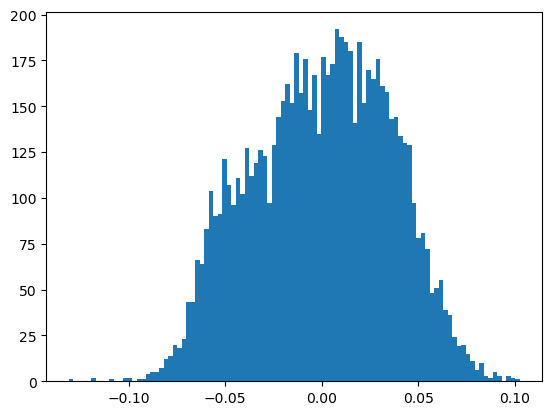

In [17]:
plt.hist(test_accuracy_word,100);

# UNDER CONSTRUCTION: PROCEED WITH CAUTION
Trying to project and align volumetric data with cortical surface. Crucial for interpreting voxel predictivity with brain regions.

In [28]:
cortex.align.automatic('101', 'identity', anat_file)

Running freesurfer BBR


/home/nquazi/miniconda3/envs/xaqlab/lib/python3.10/site-packages/cortex/align.py:413: UserWarning: Defaults changed in pycortex 1.2.8. Now automatic alignment uses Freesurfer's bbregister and mri_coreg for initialization. If you want to use FSL's BBR, use the function `cortex.align.automatic_fsl` instead.
  warnings.warn(


FileNotFoundError: [Errno 2] No such file or directory: 'bbregister'

In [21]:
fmri_img = nib.load(fmri_files[run])
fmri_data = fmri_img.get_fdata()
# subject = "MNI152"  # Pycortex's built-in template
# volume = cortex.Volume(fmri_data, subject=subject, xfmname="identity")

surface = 'S1'
transform = 'fullhead'
vmin = -2
vmax = 2
cmap = 'RdBu_r'

reference_volume, affine = cortex.db.get_xfm(surface, transform, xfmtype='volume')  # Reference template
reference_affine = cortex.db.get_affine(surface)

# volume = cortex.Volume(fmri_data, subject=surface, xfmname=transform, vmin = vmin, vmax = vmax,cmap=cmap)
#
# # Quick show to visualize the data
# cortex.quickshow(volume)
# fmri_data = fmri_data.T.reshape(fmri_data.shape[0], -1)
# print("(number of time points, number of voxels)", fmri_data.shape)

KeyError: 'volume'

In [17]:
surface = "S1" # Pycortex's built-in template
transform = 'fullhead'
reference_volume, affine = cortex.db.get_xfm(surface, transform)  # Reference template
reference_affine = cortex.db.get_affine(surface)  # Transform's affine matrix

# Sanity check: Print the shapes
print(f"Input image shape: {fmri_img.shape}")
print(f"Reference volume shape: {reference_volume.shape}")


TypeError: cannot unpack non-iterable Transform object

In [34]:
# Example subject name (from PyCortex database)
surface = 'UTS02'
transform = 'UTS02_auto'
vmin = -2
vmax = 2
cmap = 'RdBu_r'

# Convert fMRI data to PyCortex Volume format using the mask
# Ensure masked_tensor is of shape: (T, N_voxels)
volume = cortex.Volume(fmri_data, subject=surface, xfmname=transform, vmin = vmin, vmax = vmax,cmap=cmap)

# Visualize the data in PyCortex
cortex.quickshow(volume)


ValueError: Cannot find a valid mask

In [ ]:
from cortex import mni

s1_to_mni = mni.compute_mni_transform(subject='S1', xfm='fullhead')
mni.transform_to_mni()

In [10]:
from cortex import mni

np.random.seed(1234)
os.environ['FSLDIR'] = os.path.join('~','fsl')
# This transform is gonna be from one specific functional space for a subject
# which is defined by the transform (xfm)
s1_to_mni = mni.compute_mni_transform(subject='S1', xfm='fullhead')
# s1_to_mni is a 4x4 array describing the transformation in homogeneous corods

# Transform data from subject to MNI space
# first we will create a dataset to transform
data = cortex.Volume.random('S1', 'fullhead')

# then transform it!
mni_data = mni.transform_to_mni(data, s1_to_mni)
# mni_data is a nibabel Nifti1Image

mni_data_vol = mni_data.get_fdata() # the actual array, shape=(182,218,182)


Generating brainmask anatomical...
Brain masking anatomical...
Calling: bet /home/nquazi/miniconda3/envs/xaqlab/share/pycortex/db/S1/anatomicals/raw.nii.gz /home/nquazi/miniconda3/envs/xaqlab/share/pycortex/db/S1/anatomicals/brainmask.nii.gz -B -v


/bin/sh: 1: bet: not found


AssertionError: Error calling fsl-bet

We can retrieve the events over time for this run, where the TR is 2, but you'll quickly notice a problem.

In [44]:
events = pd.read_table(table_files[run])
events

,onset,duration,trial_type
0,8,2,novelObject_correctCo-location_activeLeft
1,10,2,knownObject_incorrectCo-location_activeRight
2,14,2,knownObject_incorrectCo-location_activeLeft
3,16,2,catch
4,18,2,knownObject_incorrectCo-location_activeRight
...,...,...,...
139,350,2,novelObject_correctCo-location_activeLeft
140,352,2,knownObject_incorrectCo-location_activeRight
141,354,2,novelObject_correctCo-location_activeLeft
142,356,2,knownObject_incorrectCo-location_activeLeft


The fields are bloody useless! Fortunately, with some data wrangling we can retrieve the object identities for each pair of stimuli along with the timing information. Each tuple represents (TR, condition, object 1, object 2).

In [47]:
run = 0
utils.get_stimuli_run(data_path, run)

[(1, np.int64(2), 6, 'bottle', 'glass cup'),
 (1, np.int64(6), 5, 'kettle', 'bowl'),
 (1, np.int64(8), 9, 'wrench', 'hardware nut'),
 (1, np.int64(10), 6, 'spoon', 'bowl'),
 (1, np.int64(12), 2, 'kettle', 'bowl'),
 (1, np.int64(18), 1, 'bottle', 'mug'),
 (1, np.int64(20), 1, 'bottle', 'glass cup'),
 (1, np.int64(22), 5, 'bottle', 'mug'),
 (1, np.int64(24), 5, 'pitcher', 'bowl'),
 (1, np.int64(34), 6, 'bottle', 'mug'),
 (1, np.int64(36), 9, 'tennis racket', 'ball'),
 (1, np.int64(42), 9, 'bottle', 'bowl'),
 (1, np.int64(44), 2, 'plier', 'hardware nail'),
 (1, np.int64(46), 9, 'kettle', 'bowl'),
 (1, np.int64(48), 2, 'pitcher', 'bowl'),
 (1, np.int64(50), 2, 'kettle', 'mug'),
 (1, np.int64(52), 2, 'screwdriver', 'hardware screw'),
 (1, np.int64(56), 9, 'bottle', 'bowl'),
 (1, np.int64(58), 6, 'hammer', 'hardware nail'),
 (1, np.int64(68), 1, 'wrench', 'hardware nut'),
 (1, np.int64(70), 2, 'bottle', 'mug'),
 (1, np.int64(76), 9, 'pitcher', 'mug'),
 (1, np.int64(80), 6, 'bottle', 'bowl'),